# Quick check for the AWS trained autoencoder models


In [1]:
import json
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import h5py
import pandas as pd

import sys
sys.path.append('/home/kurgyis/Research/VideoAnalysisTools/src/')
from behavioral_autoencoder.models import AutoEncoder


In [15]:
runs = ['20260827-165614', #fast cycle on largest session
        '20260827-165607',] # original parameters on largest session

runs_folder = '/mnt/m/Data/VideoAnalysisTools/runs/'

single_sess_folder = '/kd104_twNew_20221124_104921/checkpoints/kd104/'

checkpoint_nums = ['599','1499','3499','7499']

In [31]:
_session_training_dir = os.listdir(runs_folder + runs[0] + single_sess_folder)

checkpoints_dir = runs_folder + runs[1] + single_sess_folder + _session_training_dir[0] + '/'
os.listdir(checkpoints_dir)

['best_model.pt',
 'checkpoint_epoch_1099.pt',
 'checkpoint_epoch_1199.pt',
 'checkpoint_epoch_1299.pt',
 'checkpoint_epoch_1399.pt',
 'checkpoint_epoch_1499.pt',
 'checkpoint_epoch_1599.pt',
 'checkpoint_epoch_1699.pt',
 'checkpoint_epoch_1799.pt',
 'checkpoint_epoch_1899.pt',
 'checkpoint_epoch_199.pt',
 'checkpoint_epoch_1999.pt',
 'checkpoint_epoch_2099.pt',
 'checkpoint_epoch_2199.pt',
 'checkpoint_epoch_2299.pt',
 'checkpoint_epoch_2399.pt',
 'checkpoint_epoch_2499.pt',
 'checkpoint_epoch_2599.pt',
 'checkpoint_epoch_2699.pt',
 'checkpoint_epoch_2799.pt',
 'checkpoint_epoch_2899.pt',
 'checkpoint_epoch_299.pt',
 'checkpoint_epoch_2999.pt',
 'checkpoint_epoch_3099.pt',
 'checkpoint_epoch_3199.pt',
 'checkpoint_epoch_3299.pt',
 'checkpoint_epoch_3399.pt',
 'checkpoint_epoch_3499.pt',
 'checkpoint_epoch_3599.pt',
 'checkpoint_epoch_3699.pt',
 'checkpoint_epoch_3799.pt',
 'checkpoint_epoch_3899.pt',
 'checkpoint_epoch_399.pt',
 'checkpoint_epoch_3999.pt',
 'checkpoint_epoch_4099.pt',

In [34]:
config_file = checkpoints_dir + 'config.json'
with open(config_file, 'r') as f:
    config = json.load(f)

ae = AutoEncoder(config['model'])

checkpoint_data = torch.load(checkpoints_dir + 'checkpoint_epoch_' + 
                             checkpoint_nums[2] + '.pt', 
                             map_location='cpu', weights_only=False)

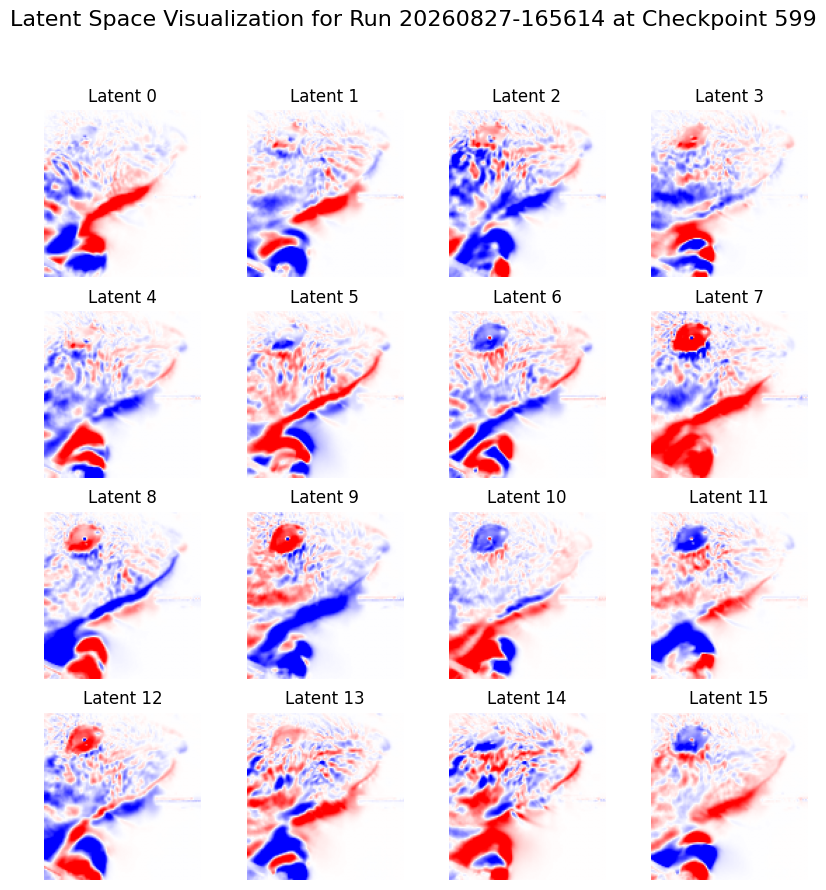

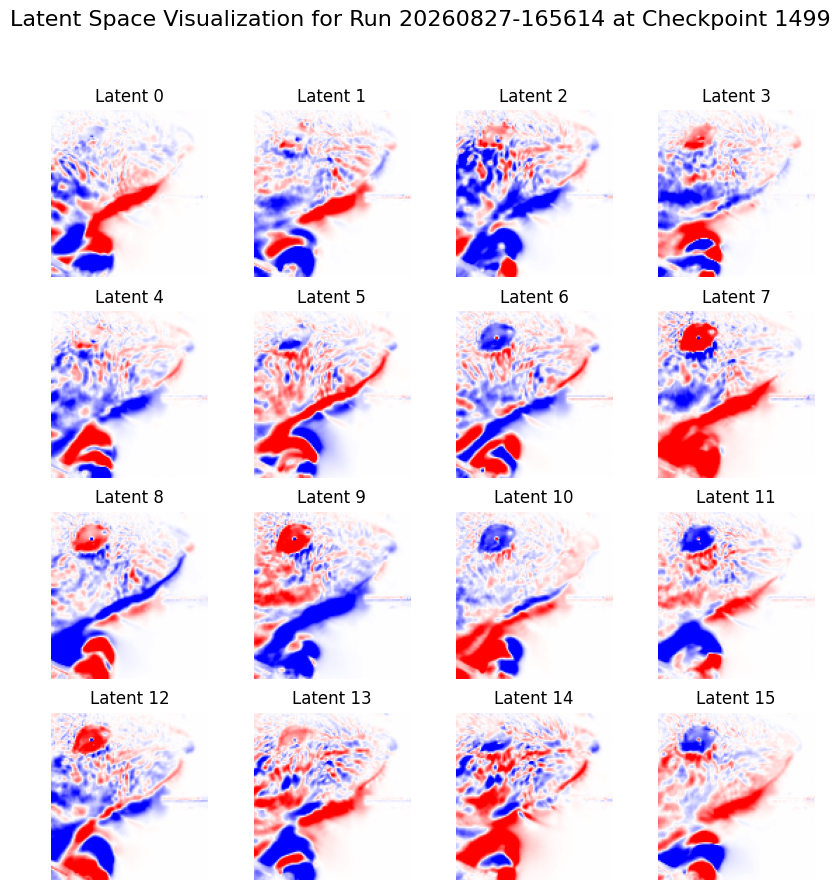

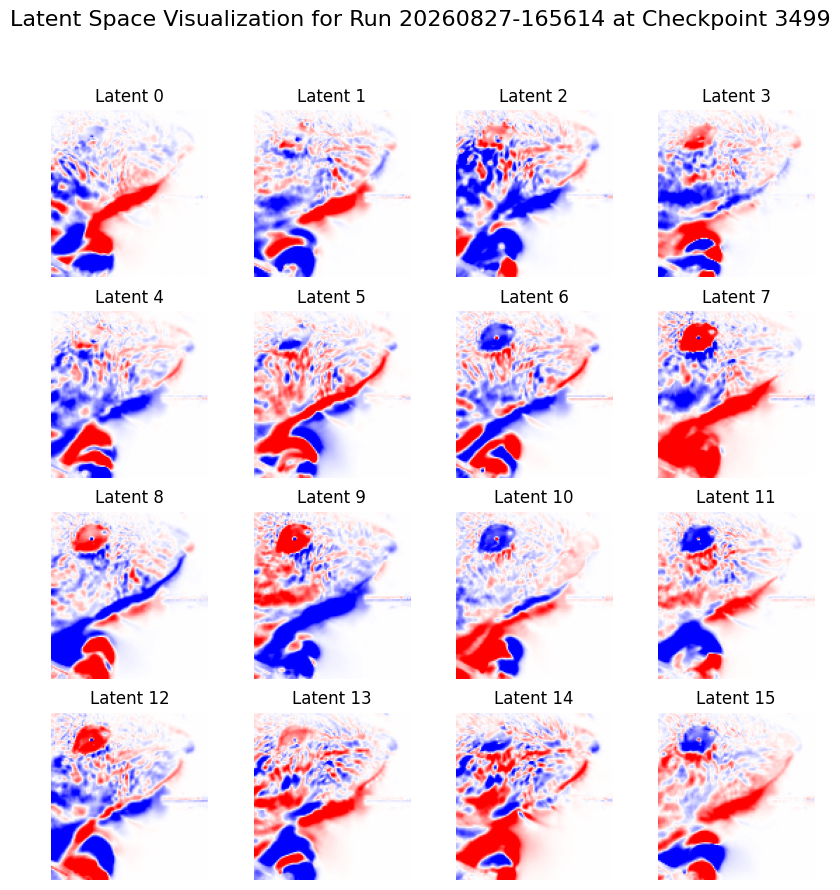

In [35]:
for i in range(3):
    ae = AutoEncoder(config['model'])

    checkpoint_data = torch.load(checkpoints_dir + 'checkpoint_epoch_' + 
                                checkpoint_nums[i] + '.pt', 
                                map_location='cpu', weights_only=False)

    ae.load_state_dict(checkpoint_data['model_state_dict'])

    f, axs = plt.subplots(4, 4, figsize=(10, 10))
    f.suptitle(f"Latent Space Visualization for Run {runs[0]} at Checkpoint {checkpoint_nums[i]}", fontsize=16)
    axs = axs.flatten()

    for i in range(16):
        input = torch.zeros((1,1,16))
        input[0,0,i] = 1

        with torch.no_grad():
            latent_image = ae.decoder(input)
            latent_image = latent_image.squeeze().numpy()
            axs[i].imshow(latent_image, cmap='bwr', vmin=-1, vmax=1)
            axs[i].set_title(f"Latent {i}")
            axs[i].axis('off')
    plt.show()
    plt.close()

In [36]:
checkpoint_data = torch.load(checkpoints_dir + 'checkpoint_epoch_' + 
                             checkpoint_nums[-1] + '.pt', 
                             map_location='cpu', weights_only=False)

In [37]:
checkpoint_data.keys()

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'config', 'val_loss', 'mean_frame_train', 'mean_frame_val', 'loss_mask', 'train_losses', 'val_losses', 'val_recon_losses', 'val_latent_losses', 'lr_history'])

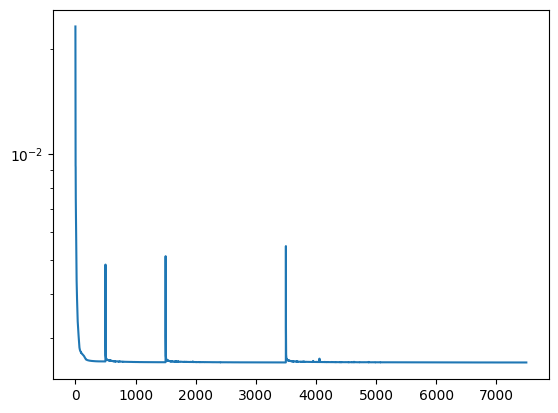

In [41]:
plt.plot(checkpoint_data['train_losses'])
#plt.plot(checkpoint_data['lr_history'])
plt.yscale('log')

In [43]:
checkpoint_data['model_state_dict']['decoder.linear_layer.bias']

tensor([-8.1477e-05,  7.6002e-05,  2.2354e-05,  ...,  2.1010e-05,
        -1.4616e-05, -8.3247e-05])

In [44]:
checkpoint_data['model_state_dict']['decoder.linear_layer.weight']

tensor([[-4.8292e-03, -1.1801e-02,  9.7864e-03,  ...,  4.6265e-02,
          6.6051e-03, -2.8503e-02],
        [-5.6482e-04, -1.7884e-02,  2.1245e-03,  ...,  5.4077e-02,
          1.8407e-02, -2.9359e-02],
        [ 1.3260e-03, -1.0201e-02, -1.1726e-02,  ...,  6.1878e-02,
          1.6384e-02, -2.9114e-02],
        ...,
        [ 2.5420e-04, -1.4334e-03, -3.2444e-03,  ...,  7.5554e-04,
          5.0507e-03, -3.4298e-05],
        [-4.6773e-05, -1.9401e-03, -4.1354e-03,  ...,  1.3906e-03,
          4.3791e-03,  4.9848e-04],
        [ 7.8416e-04, -2.4227e-03, -3.2274e-03,  ...,  2.2049e-03,
          4.7318e-03,  8.1449e-04]])

In [52]:
bias_list = []
weight_list = []

for i in range(4):
    ae = AutoEncoder(config['model'])

    checkpoint_data = torch.load(checkpoints_dir + 'checkpoint_epoch_' + 
                                checkpoint_nums[i] + '.pt', 
                                map_location='cpu', weights_only=False)

    decoder_bias, decoder_weight = checkpoint_data['model_state_dict']['decoder.linear_layer.bias'], checkpoint_data['model_state_dict']['decoder.linear_layer.weight']
    bias_list.append(decoder_bias.numpy())
    weight_list.append(decoder_weight.numpy())

In [58]:
# similarity of biases and wieghts

for i in range(4):
    for j in range(i+1, 4):
        bias_similarity = bias_list[i] @ bias_list[j] / (np.linalg.norm(bias_list[i]) * np.linalg.norm(bias_list[j]))
        weight_similarity = weight_list[i].T @ weight_list[j] / (np.linalg.norm(weight_list[i]) * np.linalg.norm(weight_list[j]))
        print(f"Bias similarity between checkpoint {checkpoint_nums[i]} and {checkpoint_nums[j]}: {bias_similarity}")
        #print(f"Weight similarity between checkpoint {checkpoint_nums[i]} and {checkpoint_nums[j]}: {weight_similarity}")

Bias similarity between checkpoint 599 and 1499: 0.6141177415847778
Bias similarity between checkpoint 599 and 3499: 0.5593955516815186
Bias similarity between checkpoint 599 and 7499: 0.271302729845047
Bias similarity between checkpoint 1499 and 3499: 0.9442077279090881
Bias similarity between checkpoint 1499 and 7499: 0.75163334608078
Bias similarity between checkpoint 3499 and 7499: 0.855340301990509


In [51]:
len(bias_list)

1